In [3]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

import datetime
import os
import shutil

matplotlib.rcParams['agg.path.chunksize'] = 1000
from glob import glob

matplotlib.style.use('../figure_style_2column_singleplot.mplstyle')

In [4]:
# VARS: GPD, BC, CO, BASE PATH

gpds = [64,80,96,128]
bcs= ["fwbbc", "hwbbc2", "ibb1c2"]
cos = ["bgk", "kbc"]

base_path = "/home/mbille/Documents/cluster_hbrs_home/02_lbm_simulations/data_240717_c2d_forLOGLOG_GPD-plot"

In [5]:
### CREATE PATH-DICT

paths_dict = dict()

for gpd in gpds:
    for bc in bcs:
        for co in cos:
            paths_dict[str(gpd)+"_"+bc+"_"+co] = []
            dir_names = glob(base_path+"/*2d_GPD"+str(gpd)+"_"+bc+"_"+co)
            if len(dir_names)>1:
                print("(!) Warning: more than 1 simulation for:", "GPD"+str(gpd)+"_"+bc+"_"+co)
                print(dir_names)
            elif len(dir_names) == 1:
                # this is what we want: one unique simulation found
                paths_dict[str(gpd)+"_"+bc+"_"+co].append(*dir_names)

loading /home/mbille/Documents/cluster_hbrs_home/02_lbm_simulations/data_240717_c2d_forLOGLOG_GPD-plot/data_240717_163915_2d_GPD64_fwbbc_bgk
loading /home/mbille/Documents/cluster_hbrs_home/02_lbm_simulations/data_240717_c2d_forLOGLOG_GPD-plot/data_240717_163916_2d_GPD64_fwbbc_kbc
loading /home/mbille/Documents/cluster_hbrs_home/02_lbm_simulations/data_240717_c2d_forLOGLOG_GPD-plot/data_240717_182912_2d_GPD64_hwbbc2_bgk
loading /home/mbille/Documents/cluster_hbrs_home/02_lbm_simulations/data_240717_c2d_forLOGLOG_GPD-plot/data_240718_013622_2d_GPD64_hwbbc2_kbc
loading /home/mbille/Documents/cluster_hbrs_home/02_lbm_simulations/data_240717_c2d_forLOGLOG_GPD-plot/data_240718_085110_2d_GPD64_ibb1c2_bgk
loading /home/mbille/Documents/cluster_hbrs_home/02_lbm_simulations/data_240717_c2d_forLOGLOG_GPD-plot/data_240718_124024_2d_GPD64_ibb1c2_kbc
loading /home/mbille/Documents/cluster_hbrs_home/02_lbm_simulations/data_240717_c2d_forLOGLOG_GPD-plot/data_240717_163915_2d_GPD80_fwbbc_bgk
loading /

/tmp/ipykernel_6620/1115742805.py:18: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(constrained_layout=True)


loading /home/mbille/Documents/cluster_hbrs_home/02_lbm_simulations/data_240717_c2d_forLOGLOG_GPD-plot/data_240718_014933_2d_GPD128_hwbbc2_kbc
loading /home/mbille/Documents/cluster_hbrs_home/02_lbm_simulations/data_240717_c2d_forLOGLOG_GPD-plot/data_240718_091024_2d_GPD128_ibb1c2_bgk
loading /home/mbille/Documents/cluster_hbrs_home/02_lbm_simulations/data_240717_c2d_forLOGLOG_GPD-plot/data_240718_132049_2d_GPD128_ibb1c2_kbc


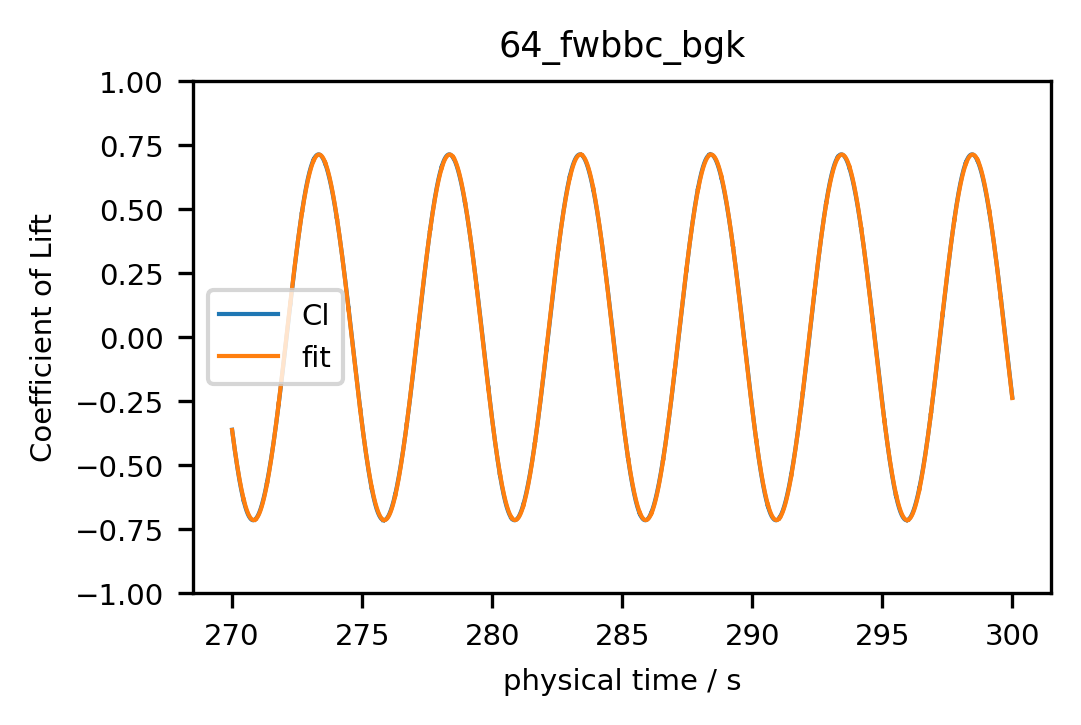

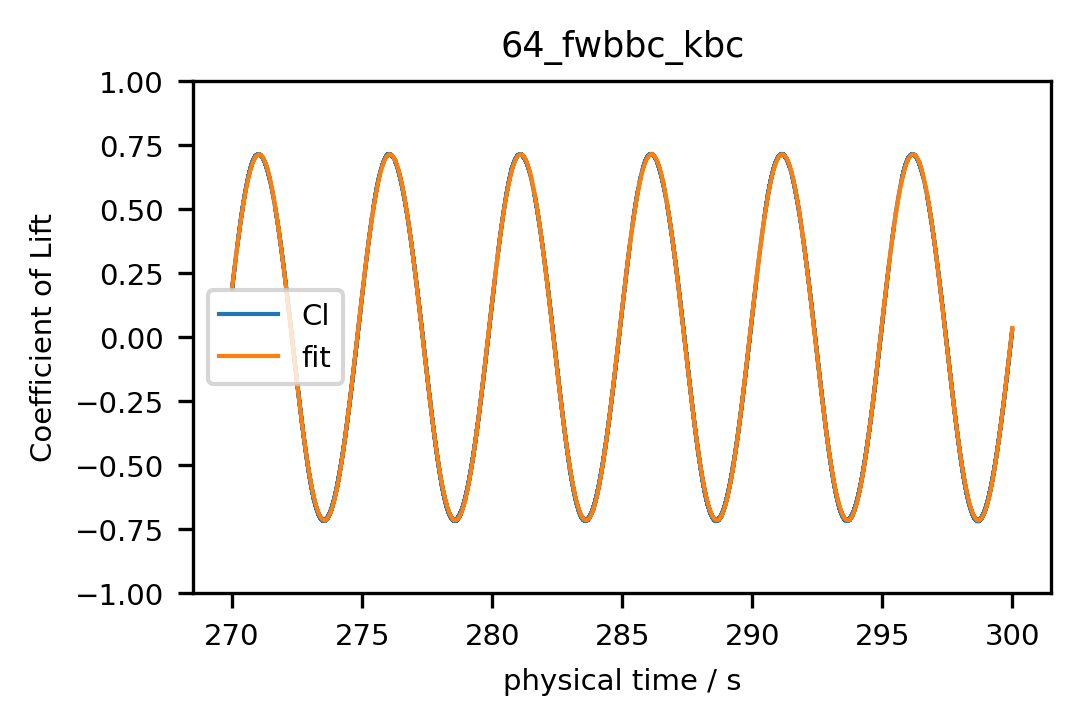

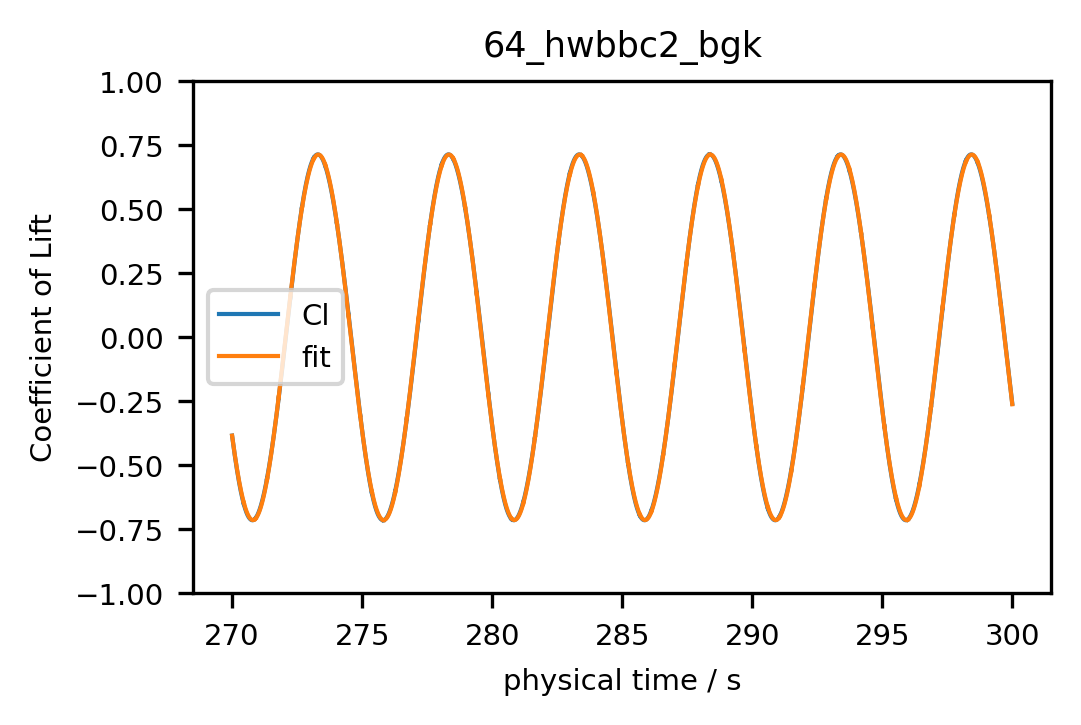

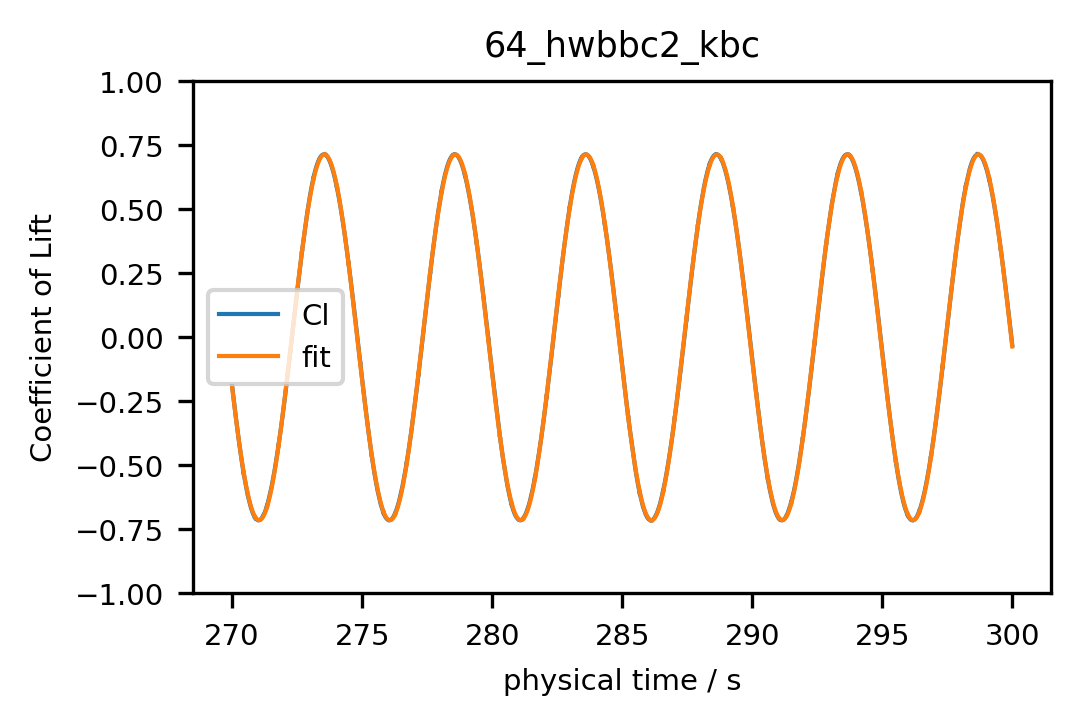

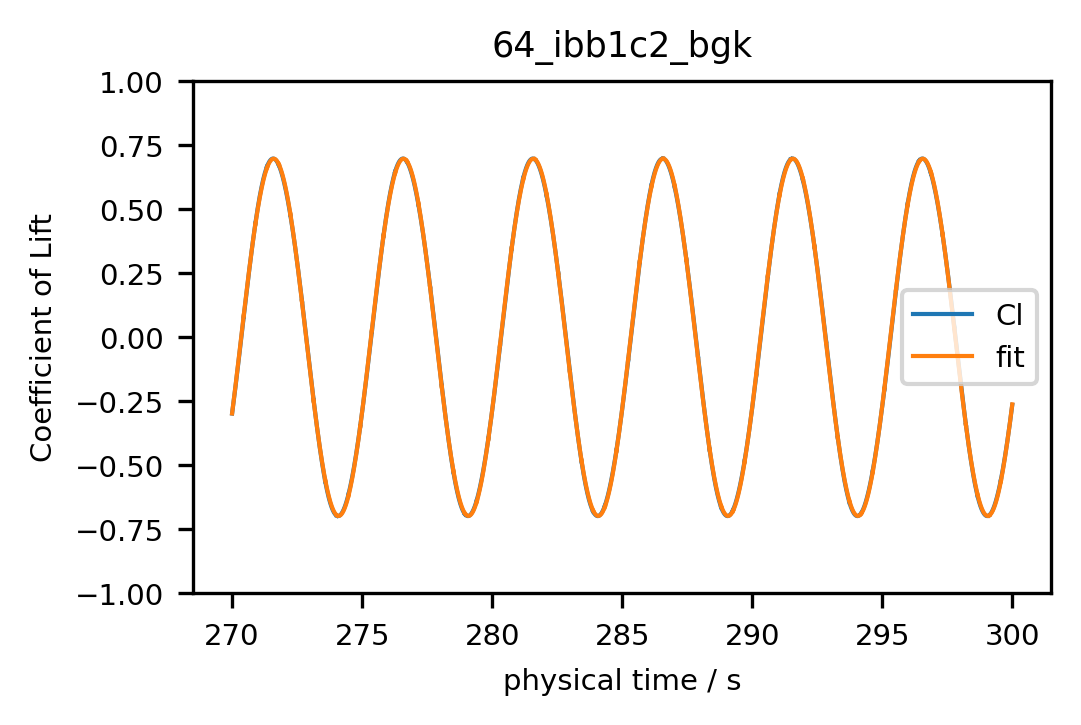

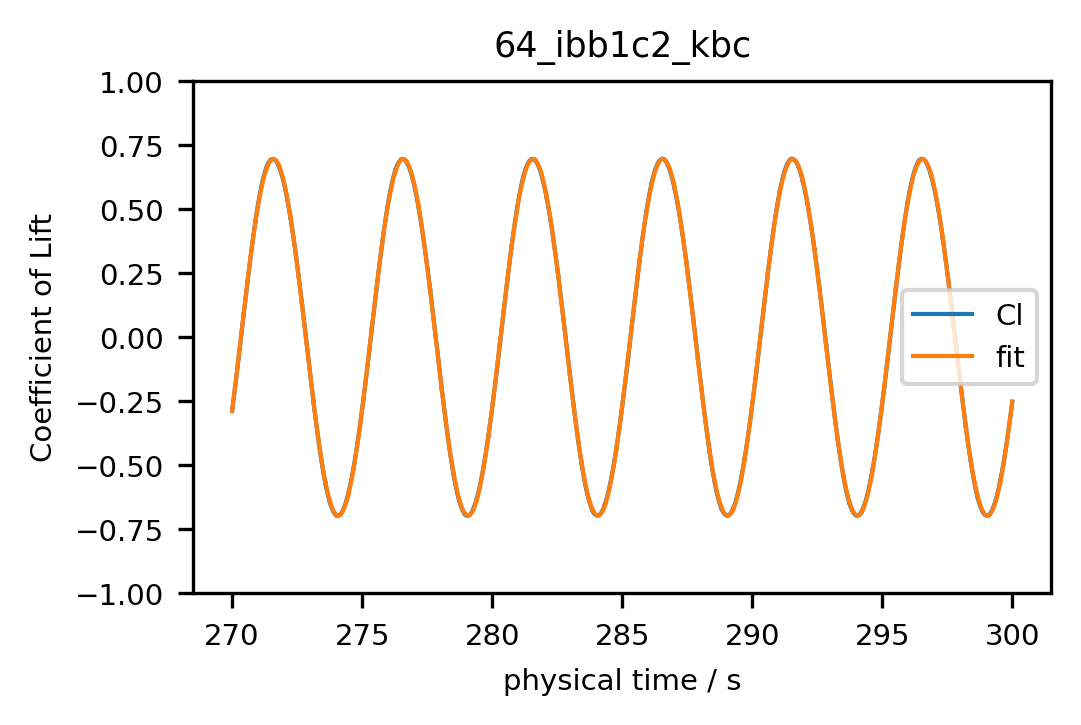

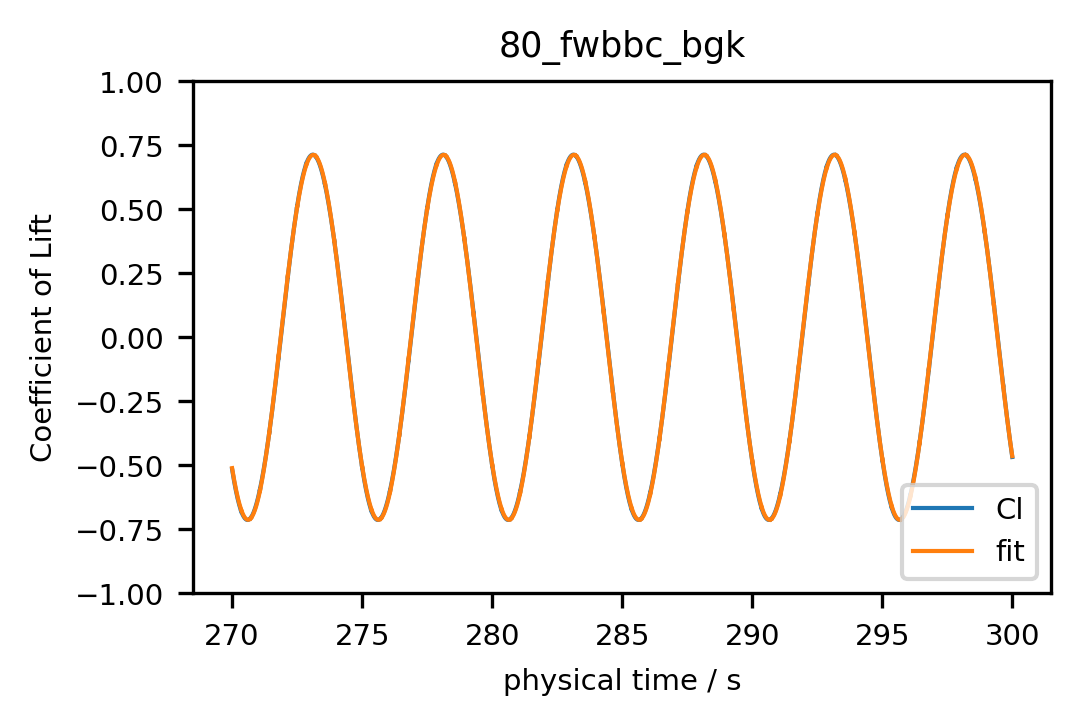

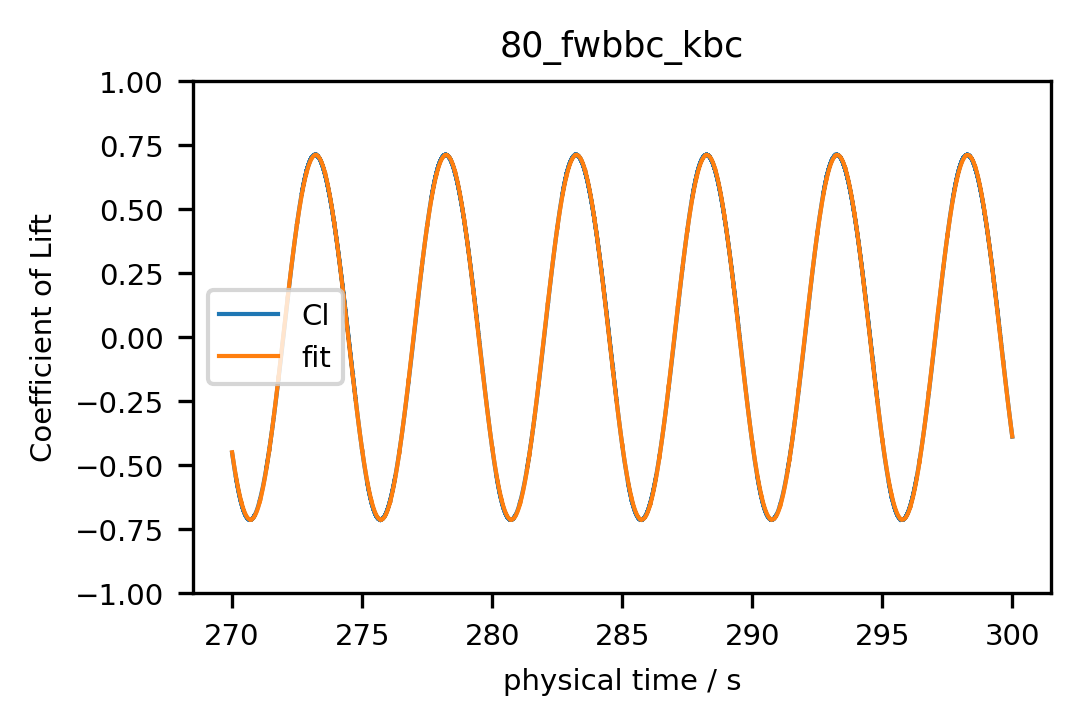

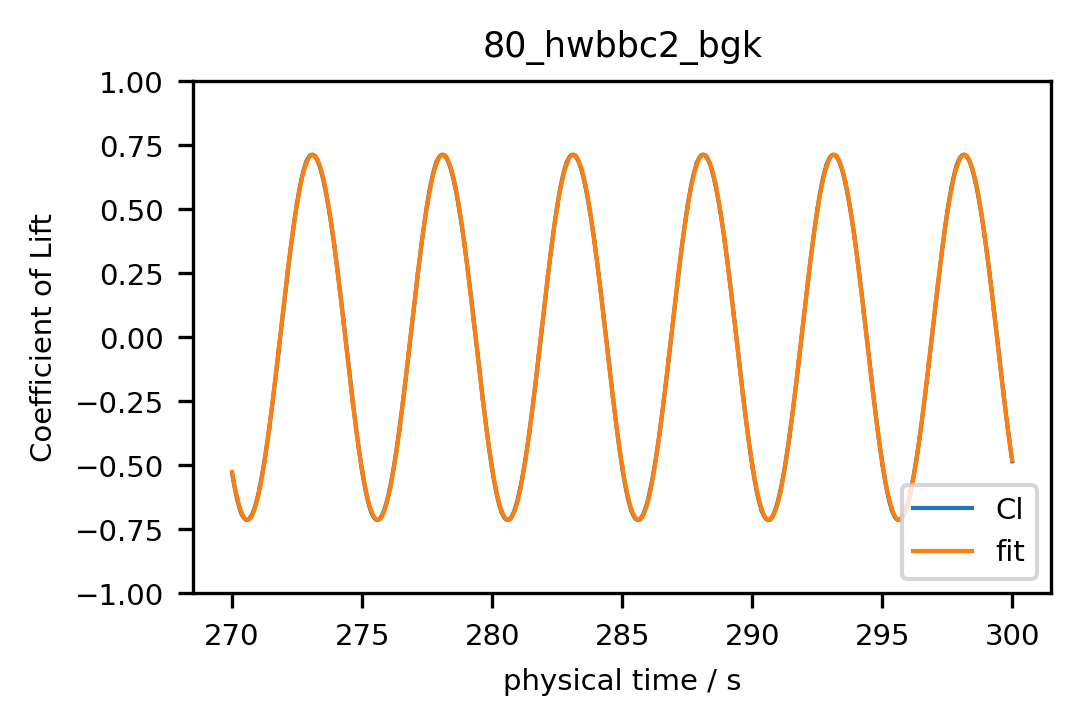

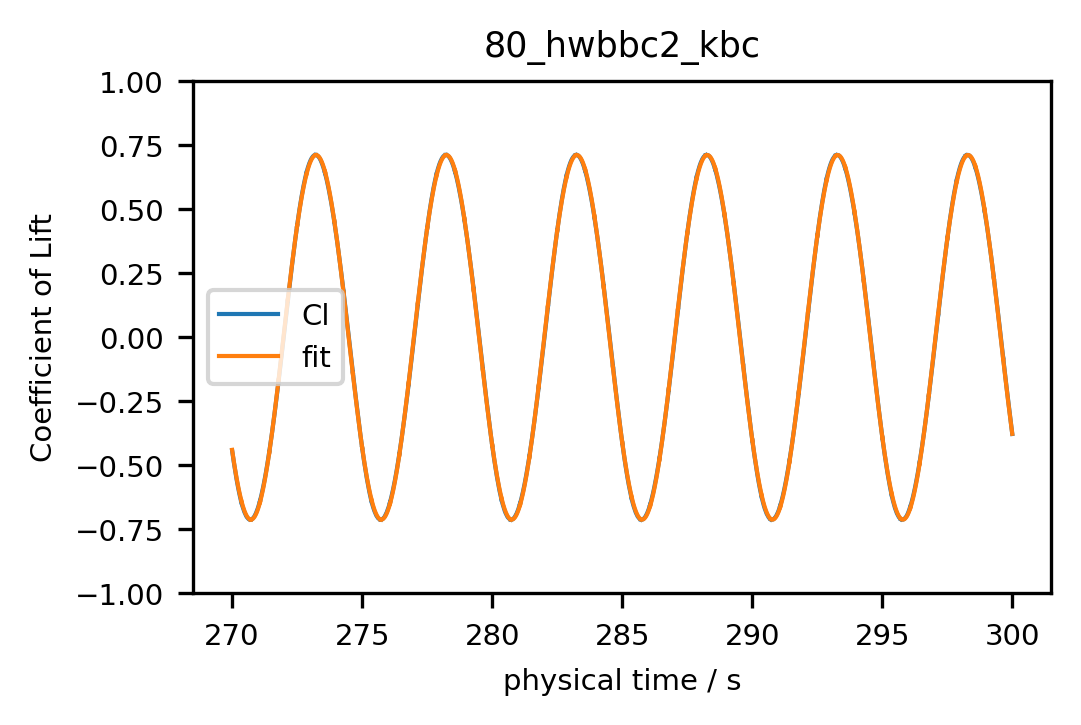

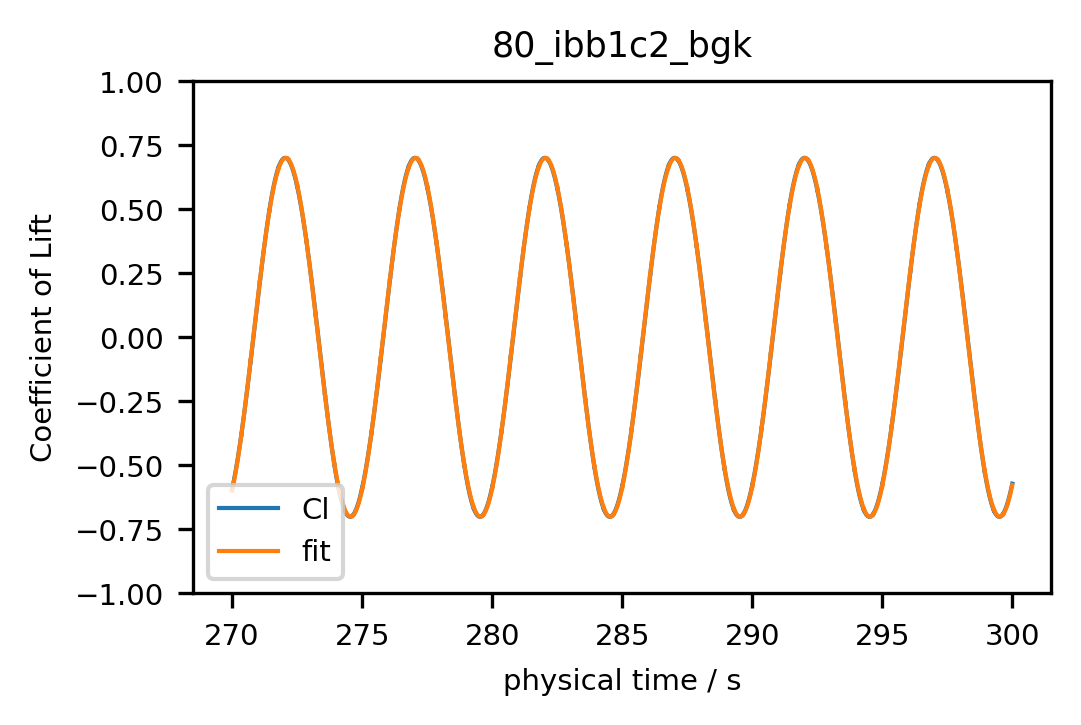

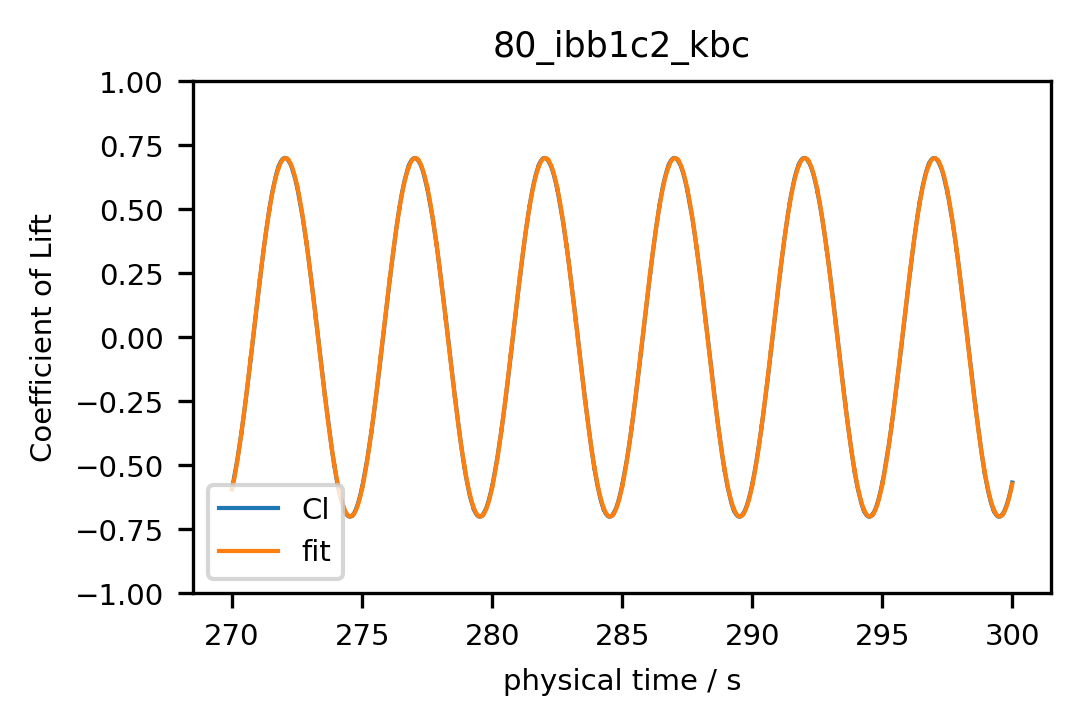

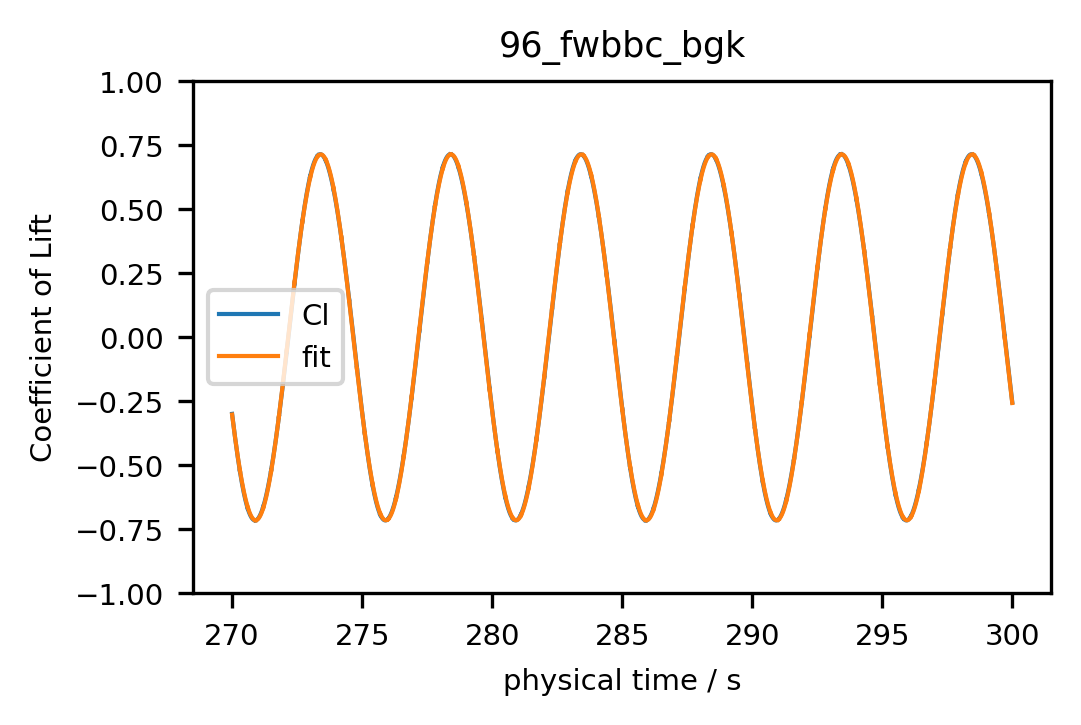

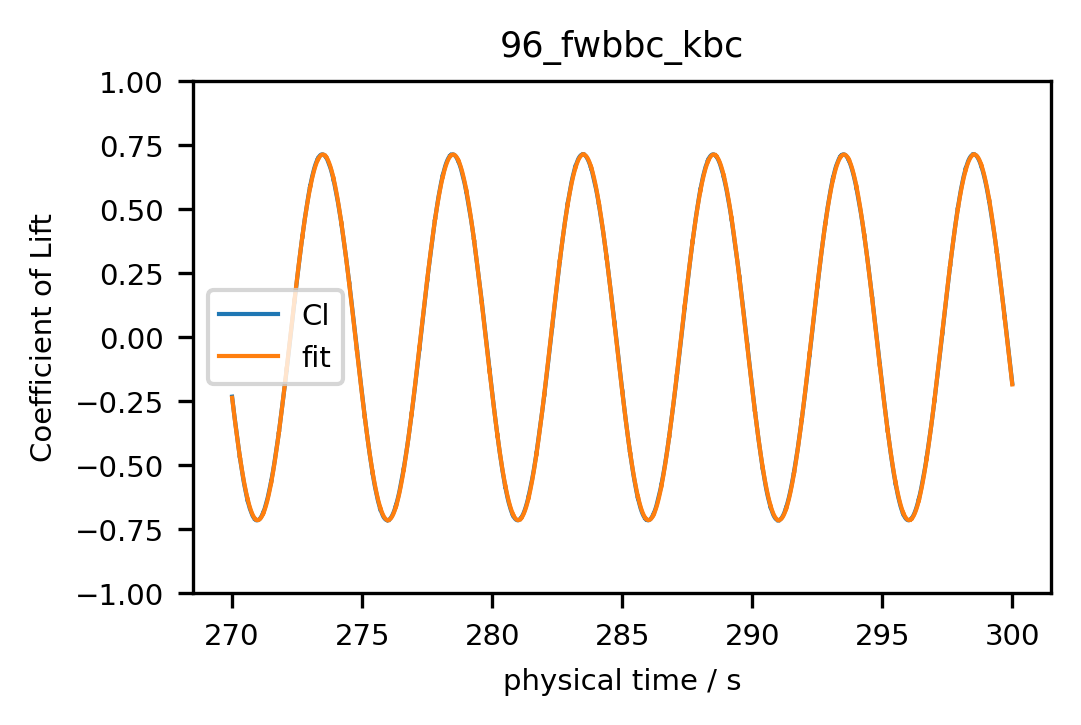

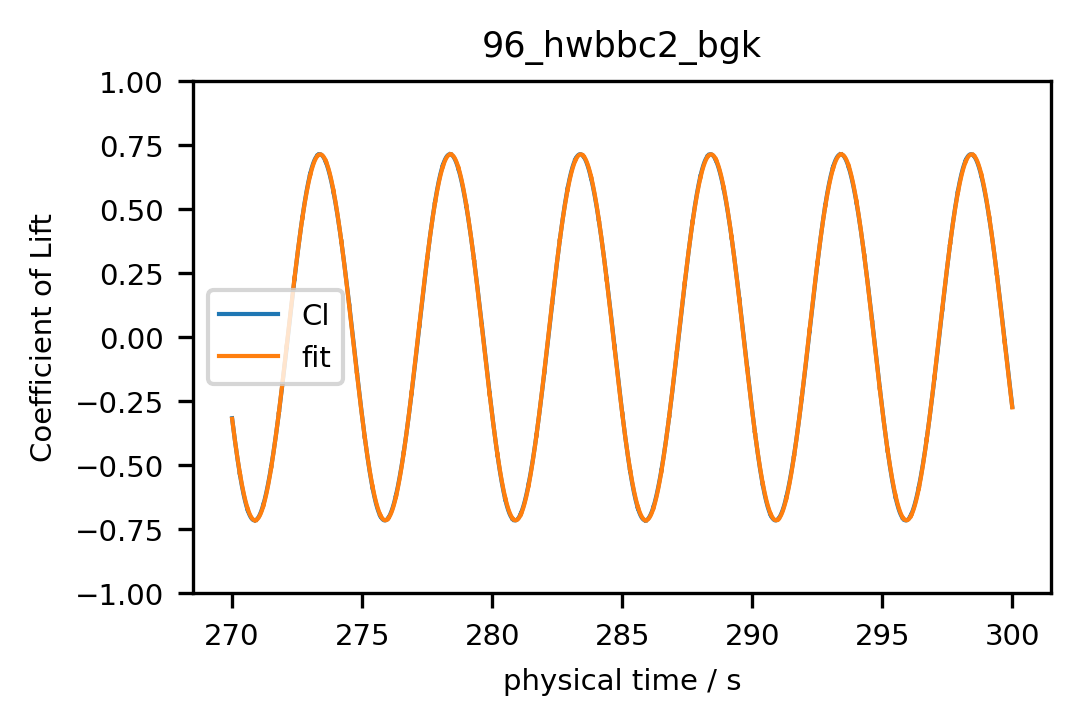

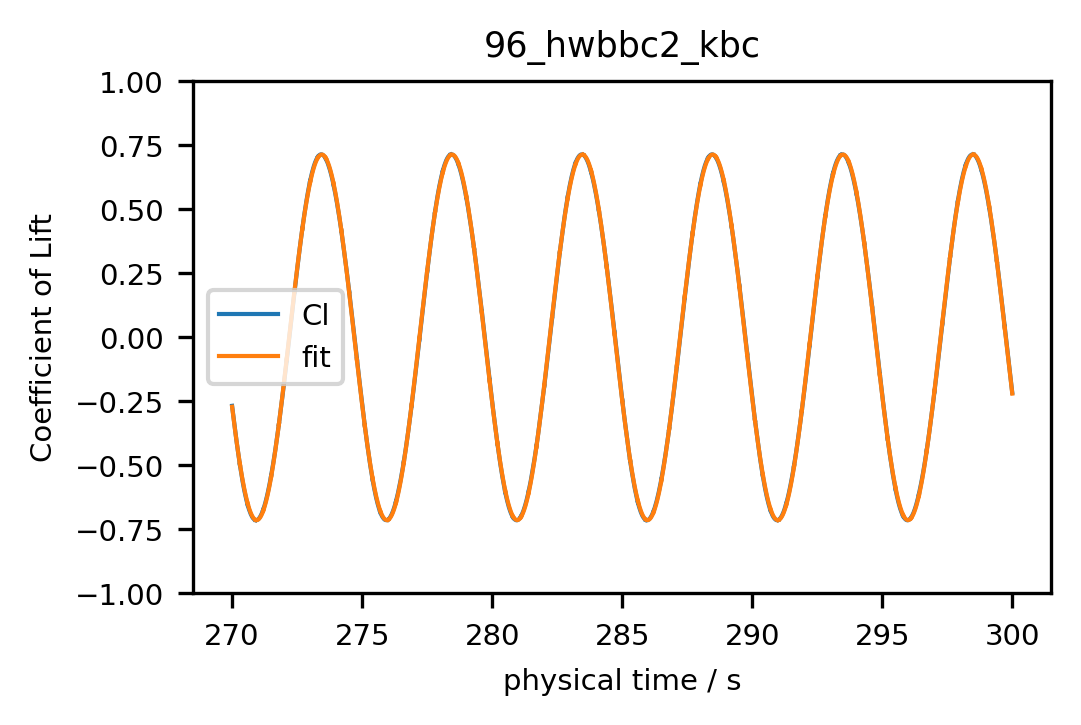

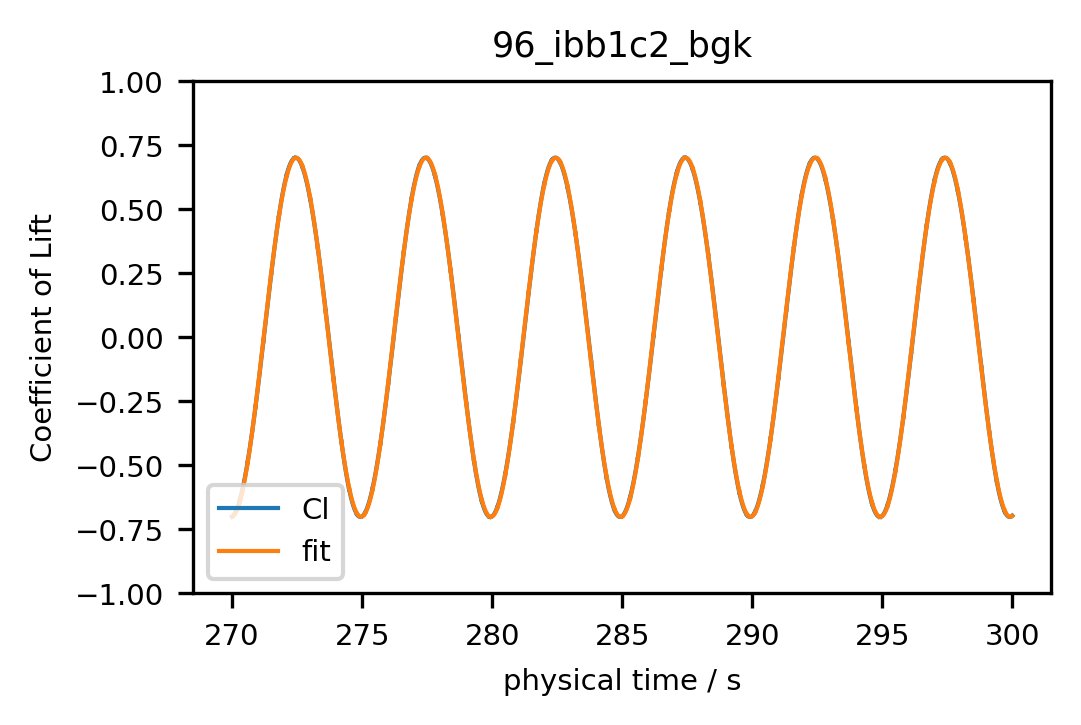

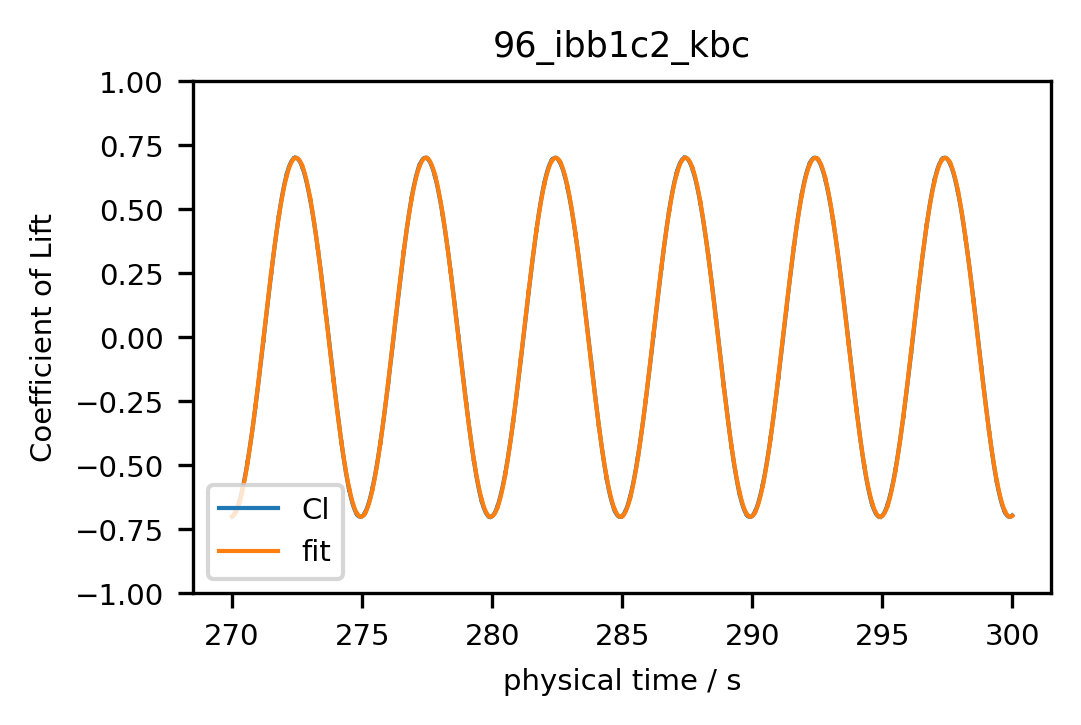

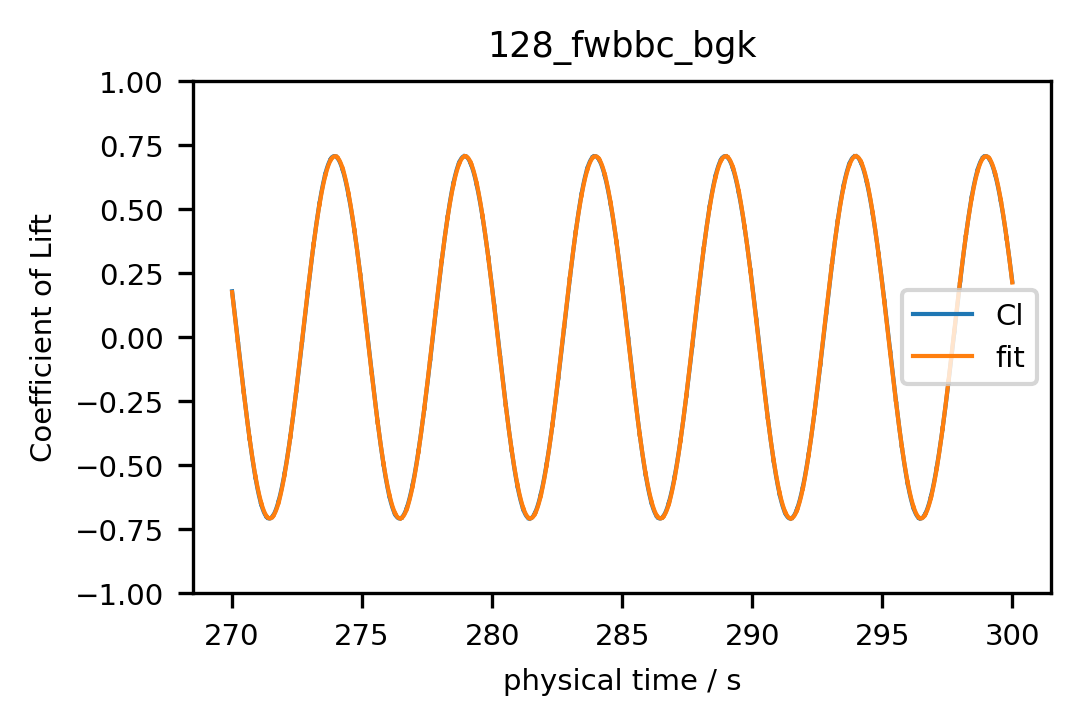

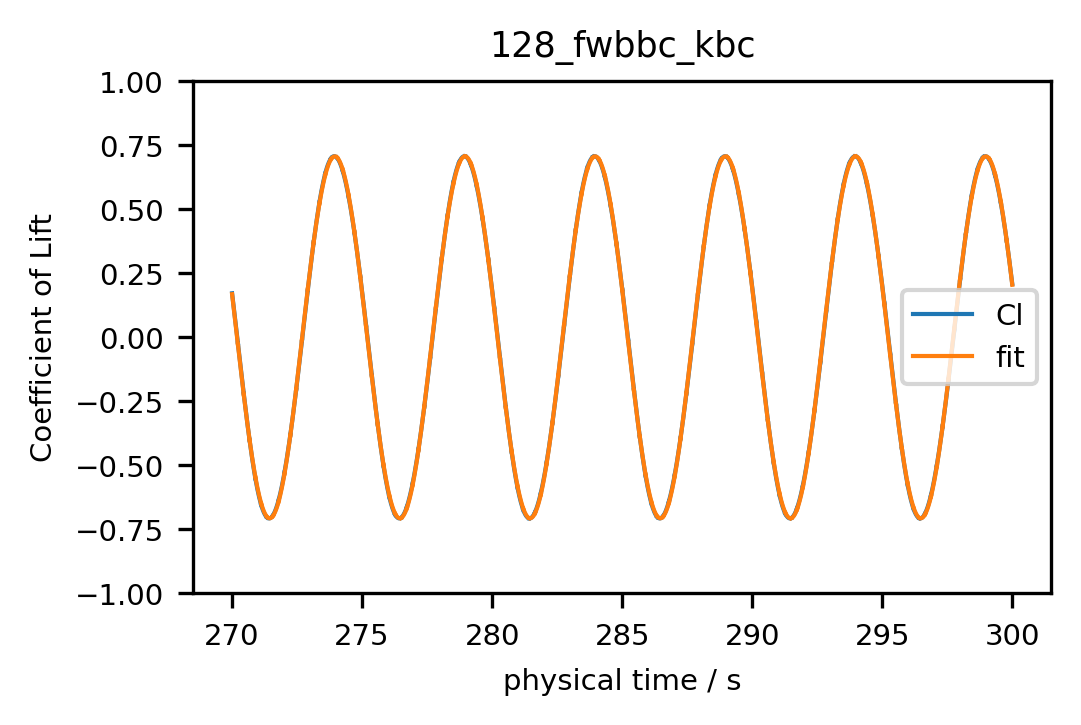

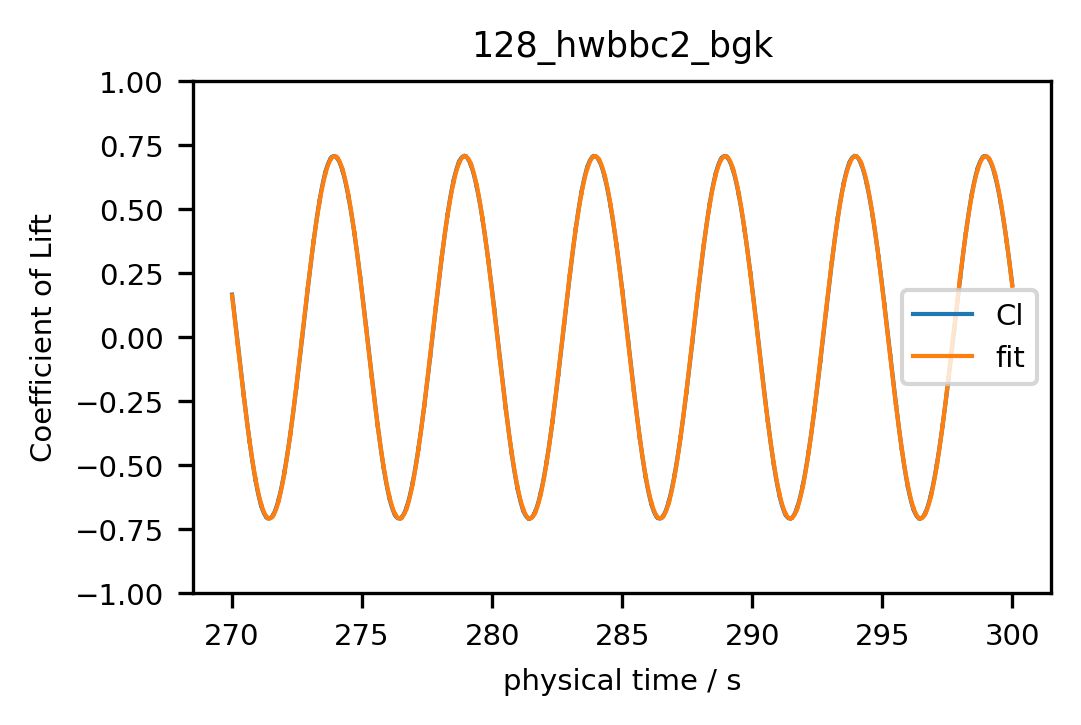

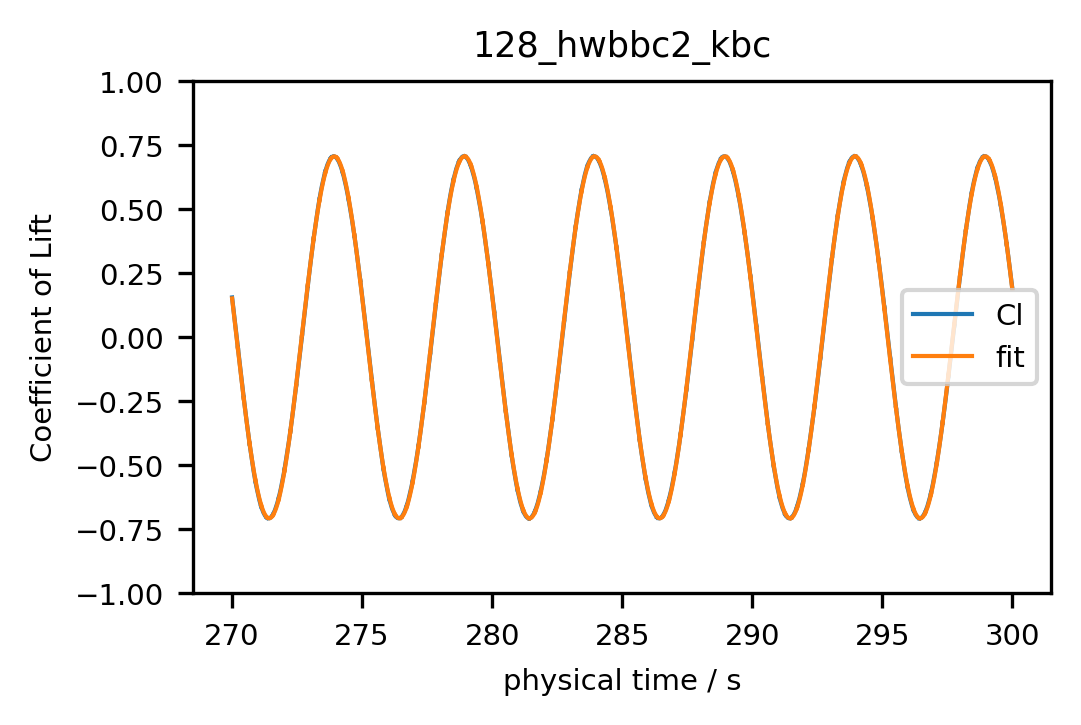

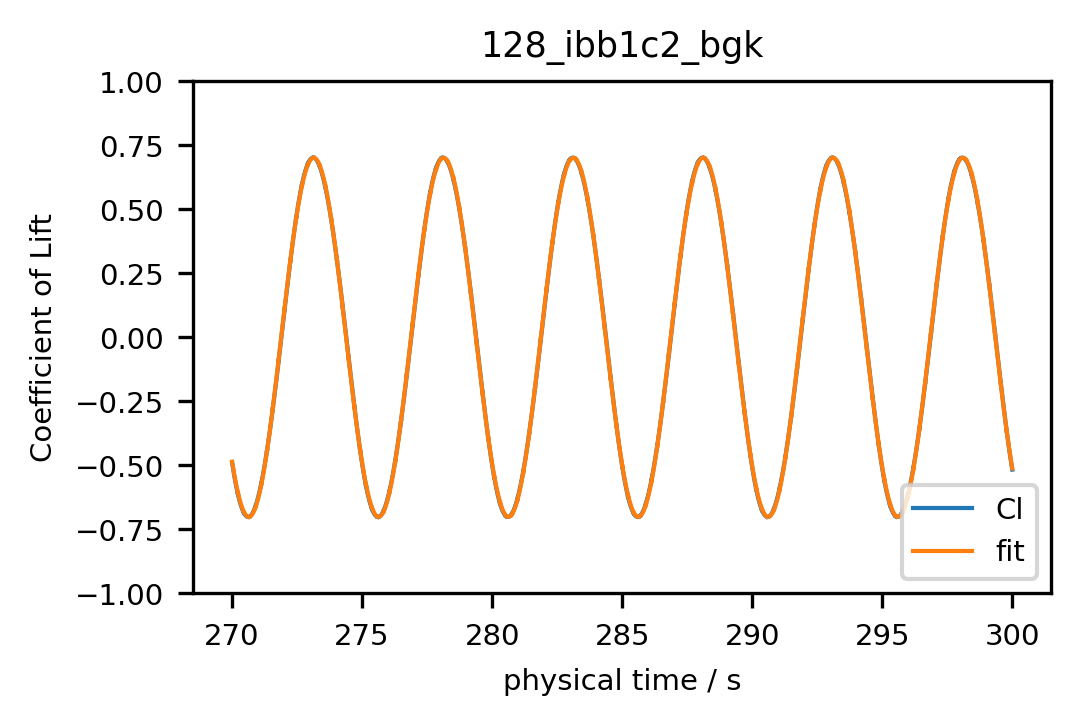

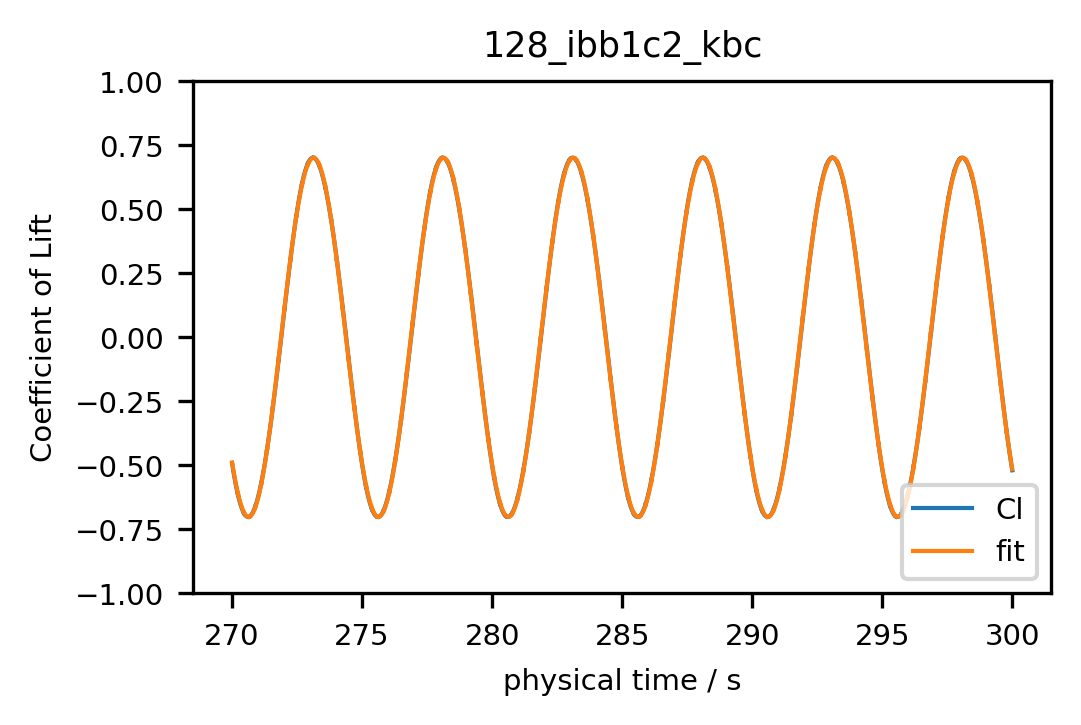

In [12]:
### LOAD Cl-timeseries and fit sine-wave

import scipy

def sine_func(xx,a,b,c,d):
    return a*np.sin(2*np.pi*b*xx+c)+d

lift_filename = "/lift_coefficient.txt"
periodic_start=0.9

data_dict = dict()  # sim_name = params, key = St-value after fit

for key in paths_dict:
    print("loading", *paths_dict[key])
    lift_timeseries = np.loadtxt(str(*paths_dict[key])+lift_filename)
    lift_converged = lift_timeseries[int(lift_timeseries.shape[0]*periodic_start-1):]
    coefficients, values = scipy.optimize.curve_fit(sine_func, lift_converged[:,1], lift_converged[:,2], p0=(0.7,0.2,0.5,0))
    fig, ax = plt.subplots(constrained_layout=True)
    plt.plot(lift_converged[:,1], lift_converged[:,2], lift_converged[:,1], sine_func(lift_converged[:,1], *coefficients))
    plt.legend(["Cl", "fit"])
    ax.set_xlabel("physical time / s")
    ax.set_ylabel("Coefficient of Lift")
    ax.set_ylim([-1,1])
    plt.title(key)
    data_dict[key] = coefficients[1]

In [13]:
# put out table of key/value pairs from gpd_bc_co: St_fit
for key in data_dict:
    print(key, data_dict[key])

64_fwbbc_bgk 0.19897296031664416
64_fwbbc_kbc 0.1988130801959097
64_hwbbc2_bgk 0.19897268497908782
64_hwbbc2_kbc 0.19880983198517793
64_ibb1c2_bgk 0.2002941645276942
64_ibb1c2_kbc 0.2003052453090432
80_fwbbc_bgk 0.19952082784963837
80_fwbbc_kbc 0.19942654640283425
80_hwbbc2_bgk 0.19952122803219055
80_hwbbc2_kbc 0.19942777417095153
80_ibb1c2_bgk 0.20029667447470795
80_ibb1c2_kbc 0.20029837095152322
96_fwbbc_bgk 0.1996330436761108
96_fwbbc_kbc 0.19959311943440772
96_hwbbc2_bgk 0.19963276301088886
96_hwbbc2_kbc 0.19959203513349724
96_ibb1c2_bgk 0.20029663908728793
96_ibb1c2_kbc 0.20029638897925917
128_fwbbc_bgk 0.19970447111886336
128_fwbbc_kbc 0.19971402598727092
128_hwbbc2_bgk 0.1997041515453989
128_hwbbc2_kbc 0.19971360423731088
128_ibb1c2_bgk 0.2002826840395726
128_ibb1c2_kbc 0.20028221441515714
